# Real Estate Listing Recommender — Full Walkthrough
**Author:** Muralimanohar Chepuri

This notebook walks through the complete recommendation pipeline:
data loading → EDA → outlier detection → feature engineering → baseline models → ALS collaborative filtering → content-based model → hybrid model.

Each section builds on the previous one, showing incremental improvement.

## 1. Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, normalize
import implicit

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)

## 2. Data Loading

In [2]:
DATA_DIR = 'data-refined'

users    = pd.read_csv(f'data-refined/users.csv')
listings = pd.read_csv(f'data-refined/cleaned_listings.csv')
likes    = pd.read_csv(f'data-refined/user_likes.csv')

In [3]:
users.head(3)

,user_id,gender,age,education
0,1,Other,69,Post Graduation
1,2,Male,66,Post Graduation
2,3,Other,66,High School


In [4]:
listings.head(3)

,listing_id,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
0,1,63921.0,for_sale,549000,4,4,5.00,705034.0,Ranburne,Alabama,36273.0,2919
1,2,3505.0,for_sale,175000,3,2,0.77,1793777.0,Fort Payne,Alabama,35967.0,1234
2,3,88491.0,for_sale,118500,3,1,0.14,1143001.0,Fort Payne,Alabama,35967.0,1276


In [5]:
likes.head(3)

,user_id,listing_id
0,1,10735
1,2,10735
2,1,15209


## 3. Exploratory Data Analysis
We explore each dataset before touching any model.

In [6]:
# Missing value audit
for name, df in [('users', users), ('listings', listings), ('likes', likes)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f'{name}: no missing values')
    else:
        print(f'{name} missing values:')
        print(missing.to_string())
        print()

users: no missing values
listings missing values:
brokered_by     8
street         28
zip_code        2

likes: no missing values


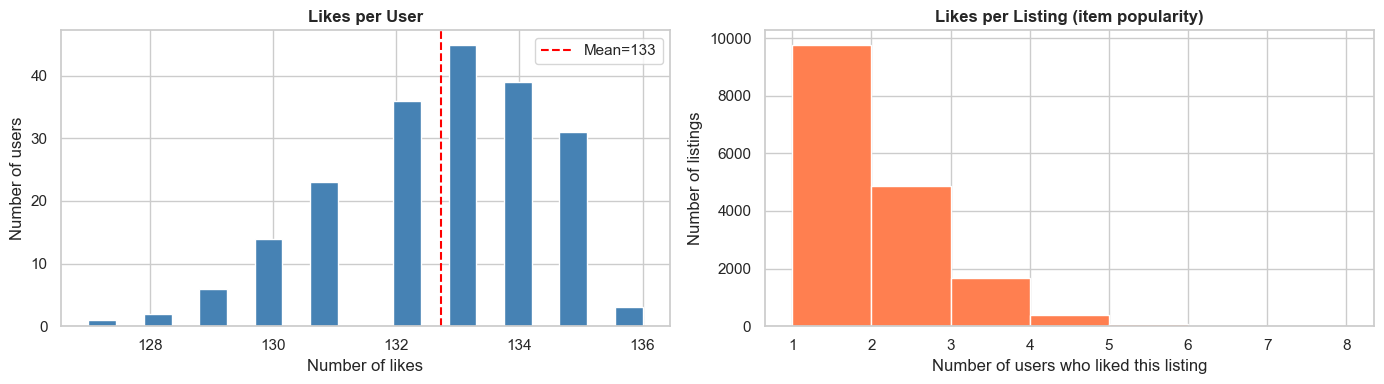

Likes per user — min: 127, max: 136, mean: 132.7
Likes per item — min: 1, max: 7, mean: 1.58

Items liked by 1 user only : 9,777 (58.2%)
Items liked by 5+ users    : 95 (0.6%)


In [7]:
likes_per_user = likes.groupby('user_id').size()
likes_per_item = likes.groupby('listing_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(likes_per_user, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Likes per User', fontweight='bold')
axes[0].set_xlabel('Number of likes'); axes[0].set_ylabel('Number of users')
axes[0].axvline(likes_per_user.mean(), color='red', linestyle='--', label=f'Mean={likes_per_user.mean():.0f}')
axes[0].legend()

axes[1].hist(likes_per_item, bins=range(1, likes_per_item.max()+2), color='coral', edgecolor='white')
axes[1].set_title('Likes per Listing (item popularity)', fontweight='bold')
axes[1].set_xlabel('Number of users who liked this listing')
axes[1].set_ylabel('Number of listings')

plt.tight_layout(); plt.show()

print(f'Likes per user — min: {likes_per_user.min()}, max: {likes_per_user.max()}, mean: {likes_per_user.mean():.1f}')
print(f'Likes per item — min: {likes_per_item.min()}, max: {likes_per_item.max()}, mean: {likes_per_item.mean():.2f}')
print(f'\nItems liked by 1 user only : {(likes_per_item == 1).sum():,} ({(likes_per_item == 1).mean():.1%})')
print(f'Items liked by 5+ users    : {(likes_per_item >= 5).sum():,} ({(likes_per_item >= 5).mean():.1%})')

In [8]:
n_users = users['user_id'].nunique()
n_items = listings['listing_id'].nunique()
n_interactions = len(likes)
sparsity = 1 - n_interactions / (n_users * n_items)

print('=== Interaction Matrix Stats ===')
print(f'Users        : {n_users}')
print(f'Items        : {n_items:,}')
print(f'Interactions : {n_interactions:,}')
print(f'Sparsity     : {sparsity:.4%}')
print(f'Density      : {1-sparsity:.4%}')

# Sample pairwise user overlap (how many items any two users co-liked)
user_item_sets = likes.groupby('user_id')['listing_id'].apply(set)
uid_sample = list(user_item_sets.index[:30])
overlaps = [
    len(user_item_sets[uid_sample[i]] & user_item_sets[uid_sample[j]])
    for i in range(len(uid_sample)) for j in range(i+1, len(uid_sample))
]
print(f'\nPairwise user overlap (first 30 users):')
print(f'  Avg shared items : {np.mean(overlaps):.2f}')
print(f'  Max shared items : {max(overlaps)}')
print(f'\n=> Very sparse item side + near-zero user overlap = CF will struggle here.')

=== Interaction Matrix Stats ===
Users        : 200
Items        : 26,648
Interactions : 26,546
Sparsity     : 99.5019%
Density      : 0.4981%

Pairwise user overlap (first 30 users):
  Avg shared items : 0.65
  Max shared items : 4

=> Very sparse item side + near-zero user overlap = CF will struggle here.


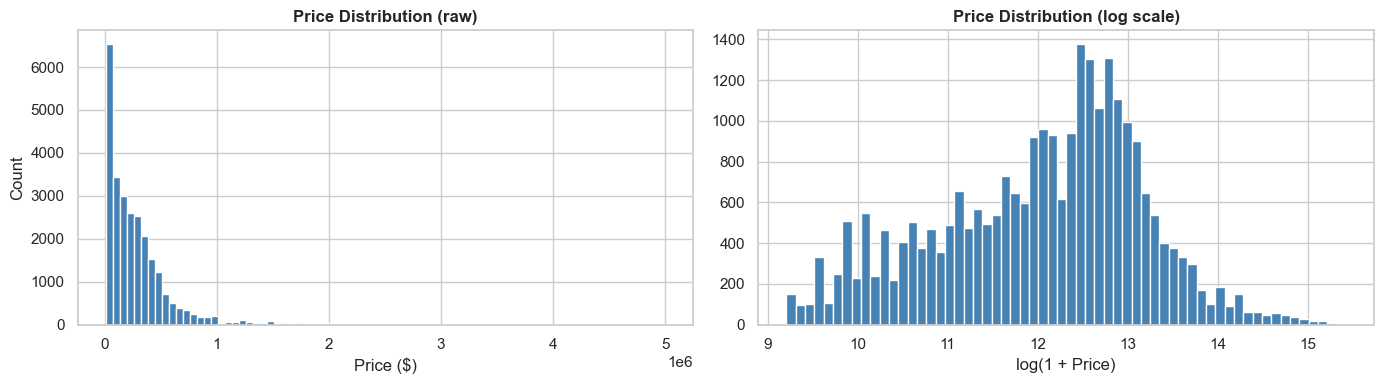

Price: min=$10,000  median=$200,000  max=$5,000,000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(listings['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (raw)', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(listings['price']), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution (log scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout(); plt.show()
print(f'Price: min=${listings["price"].min():,.0f}  median=${listings["price"].median():,.0f}  max=${listings["price"].max():,.0f}')

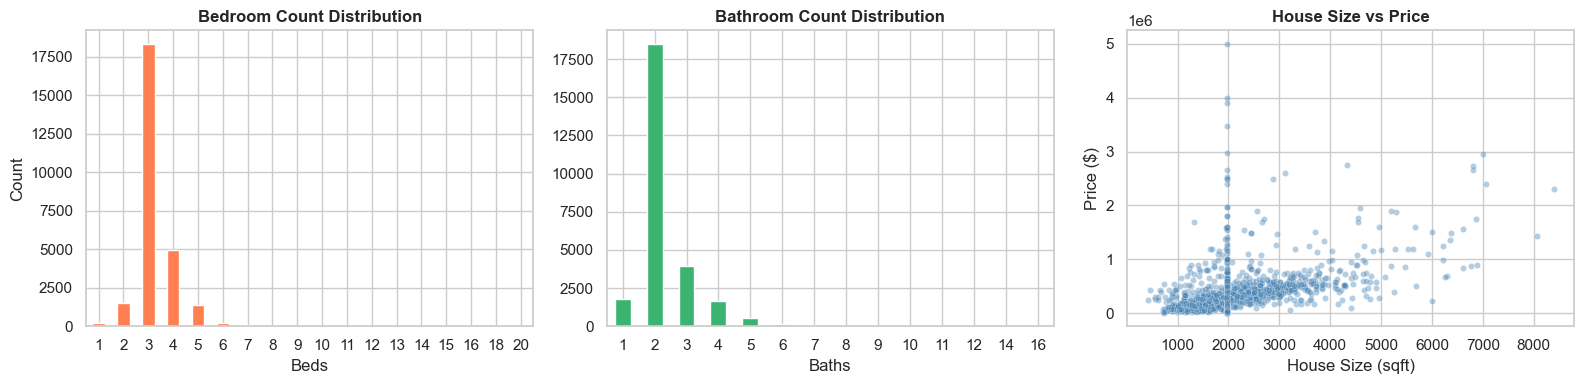

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

listings['bed'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Bedroom Count Distribution', fontweight='bold')
axes[0].set_xlabel('Beds'); axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)

listings['bath'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Bathroom Count Distribution', fontweight='bold')
axes[1].set_xlabel('Baths'); axes[1].tick_params(axis='x', rotation=0)

sns.scatterplot(data=listings.sample(2000, random_state=42), x='house_size', y='price',
                alpha=0.4, s=20, ax=axes[2], color='steelblue')
axes[2].set_title('House Size vs Price', fontweight='bold')
axes[2].set_xlabel('House Size (sqft)'); axes[2].set_ylabel('Price ($)')

plt.tight_layout(); plt.show()

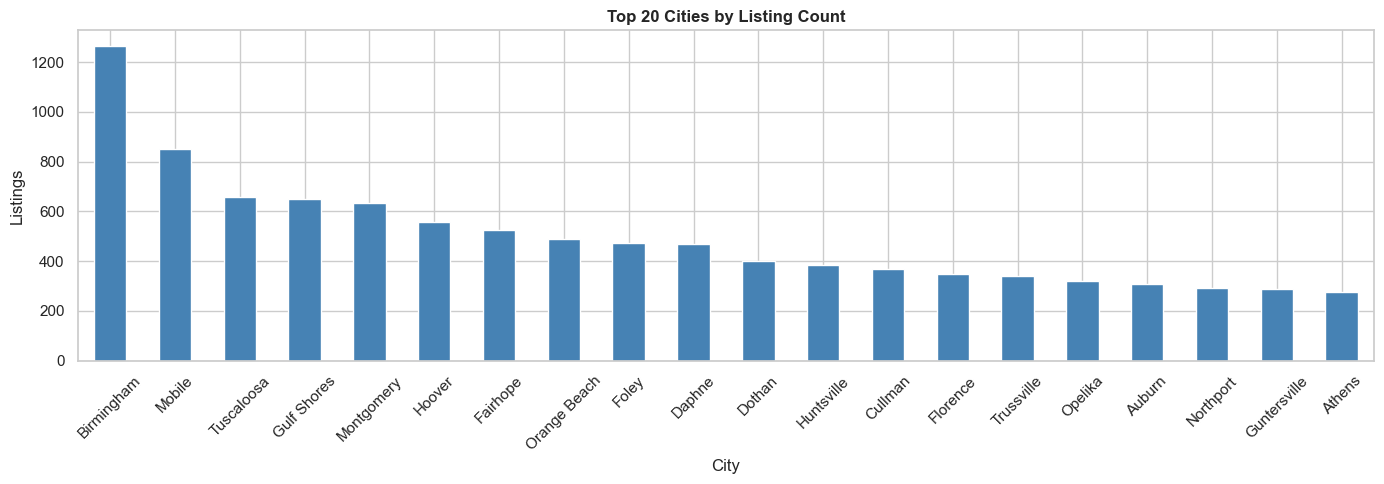

Total unique cities: 549
Top 5 cities cover 15.2% of all listings


In [11]:
top20 = listings['city'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 5))
top20.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Cities by Listing Count', fontweight='bold')
ax.set_xlabel('City'); ax.set_ylabel('Listings')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(f'Total unique cities: {listings["city"].nunique()}')
print(f'Top 5 cities cover {top20.head(5).sum()/len(listings):.1%} of all listings')

## 4. Outlier Detection
We use the **IQR (interquartile range) fence** method for numeric columns.
Values beyond `Q3 + 1.5×IQR` are flagged as high outliers and inspected.

In [12]:
def iqr_fences(series, multiplier=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - multiplier * iqr, q3 + multiplier * iqr

numeric_cols = ['price', 'bed', 'bath', 'acre_lot', 'house_size']
print(f'{'Column':<15} {'Q1':>10} {'Q3':>10} {'IQR Fence (hi)':>16} {'Outliers':>10} {'%':>7}')
print('-' * 70)
for col in numeric_cols:
    lo, hi = iqr_fences(listings[col])
    n_out = ((listings[col] < lo) | (listings[col] > hi)).sum()
    print(f'{col:<15} {listings[col].quantile(0.25):>10,.0f} {listings[col].quantile(0.75):>10,.0f} {hi:>16,.0f} {n_out:>10,} {n_out/len(listings):>7.2%}')

Column                  Q1         Q3   IQR Fence (hi)   Outliers       %
----------------------------------------------------------------------
price               75,000    377,000          830,000      1,484   5.57%
bed                      3          3                3      8,332  31.27%
bath                     2          2                2      8,191  30.74%
acre_lot                 0          1                3      4,803  18.02%
house_size           1,844      2,142            2,589      7,439  27.92%


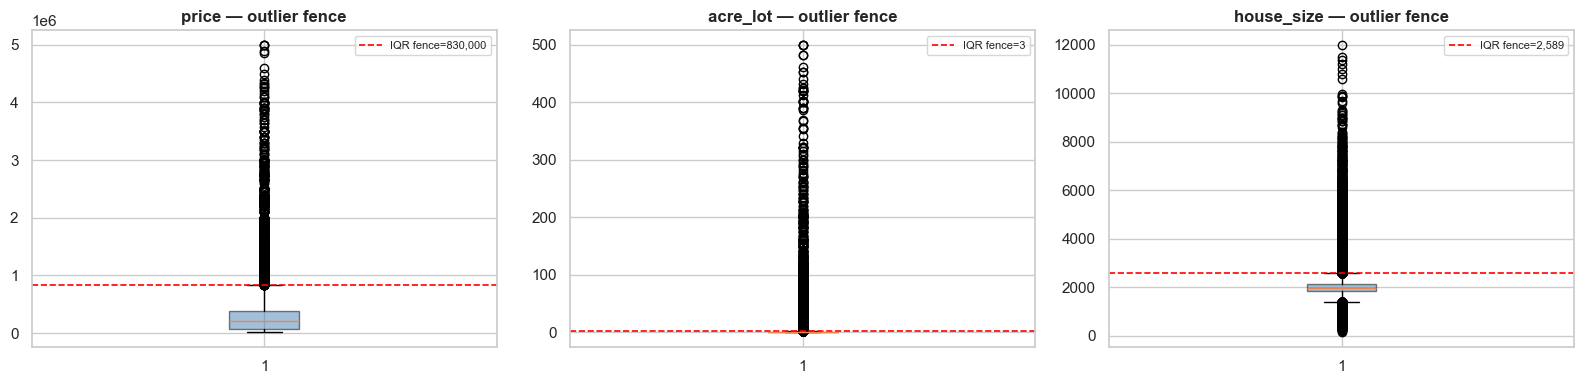

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['price', 'acre_lot', 'house_size']):
    _, hi = iqr_fences(listings[col])
    ax.boxplot(listings[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.axhline(hi, color='red', linestyle='--', linewidth=1.2, label=f'IQR fence={hi:,.0f}')
    ax.set_title(f'{col} — outlier fence', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [14]:
# Apply hard caps based on domain knowledge + IQR inspection
before = len(listings)
listings_clean = listings[
    listings['price'].between(10_000, 5_000_000) &
    listings['bed'].between(1, 20) &
    listings['bath'].between(1, 20) &
    (listings['acre_lot'] <= 500) &
    listings['house_size'].between(100, 12_000)
].copy()

# Remove likes that pointed to removed listings
likes_clean = likes[likes['listing_id'].isin(listings_clean['listing_id'])].copy()
likes_clean = likes_clean.drop_duplicates(subset=['user_id', 'listing_id'])

print(f'Listings : {before:,} → {len(listings_clean):,}  (removed {before-len(listings_clean):,})')
print(f'Likes    : {len(likes):,} → {len(likes_clean):,}  (removed {len(likes)-len(likes_clean):,})')

# Use clean versions for all downstream steps
listings = listings_clean.reset_index(drop=True)
likes    = likes_clean.reset_index(drop=True)

Listings : 26,648 → 26,648  (removed 0)
Likes    : 26,546 → 26,546  (removed 0)


## 5. Feature Engineering
Good features are the foundation of content-based similarity.
We apply three key transformations:
1. **Log-scaling** skewed numeric columns so outlier prices don't dominate distance
2. **City bucketing** to keep one-hot dimensionality manageable
3. **L2 normalization** so every listing vector has unit length (cosine = dot product)

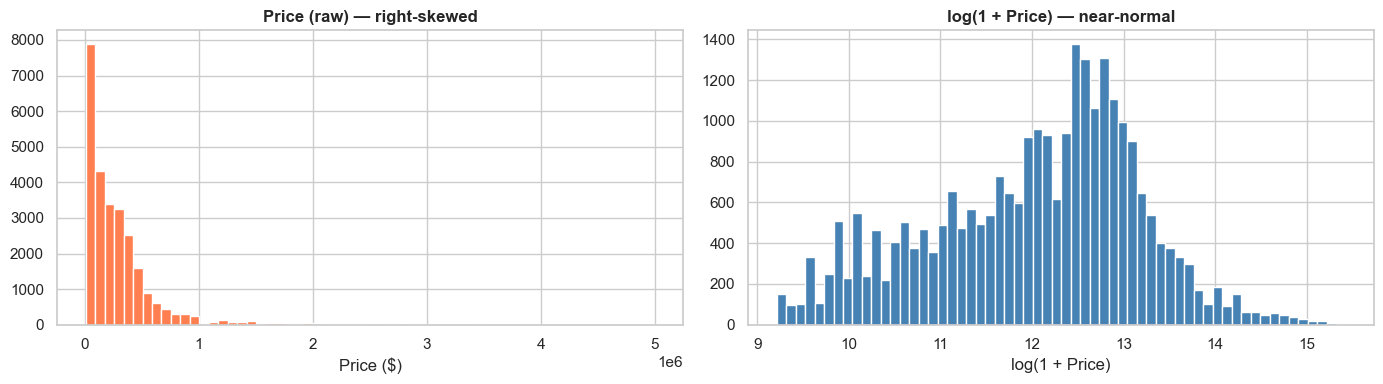

Log-transform makes similar-priced homes closer in feature space.
Without it, a $1M home would dominate distance over a $200k home unfairly.


In [15]:
# Show the effect of log-scaling on price
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(listings['price'], bins=60, color='coral', edgecolor='white')
axes[0].set_title('Price (raw) — right-skewed', fontweight='bold')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(listings['price']), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('log(1 + Price) — near-normal', fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout(); plt.show()
print('Log-transform makes similar-priced homes closer in feature space.')
print('Without it, a $1M home would dominate distance over a $200k home unfairly.')

In [16]:
TOP_CITIES = 25
top_city_list = listings['city'].value_counts().head(TOP_CITIES).index.tolist()

listings['city_bucket'] = listings['city'].where(listings['city'].isin(top_city_list), other='Other')

print(f'Unique cities     : {listings["city"].nunique()}')
print(f'Cities one-hotted : {TOP_CITIES} + "Other" = {TOP_CITIES+1} dimensions')
print(f'\nTop 5 city buckets:')
print(listings['city_bucket'].value_counts().head(6).to_string())

Unique cities     : 549
Cities one-hotted : 25 + "Other" = 26 dimensions

Top 5 city buckets:
city_bucket
Other          15555
Birmingham      1264
Mobile           851
Tuscaloosa       658
Gulf Shores      648
Montgomery       634


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, normalize

def build_item_features(df, top_cities):
    d = df.copy()
    d['log_price']      = np.log1p(d['price'])
    d['log_house_size'] = np.log1p(d['house_size'])
    d['log_acre_lot']   = np.log1p(d['acre_lot'])
    d['city_bucket']    = d['city'].where(d['city'].isin(top_cities), other='Other')

    num_cols = ['log_price', 'bed', 'bath', 'log_house_size', 'log_acre_lot']
    cat_cols = ['city_bucket', 'status']

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler(with_mean=False))]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))]), cat_cols),
    ], remainder='drop', sparse_threshold=0.0)

    X = pre.fit_transform(d)
    X = normalize(X, norm='l2', axis=1)
    return csr_matrix(X), pre

item_features, feat_pipeline = build_item_features(listings, top_city_list)
item_ids = listings['listing_id'].to_numpy()
print(f'Item feature matrix: {item_features.shape[0]:,} listings × {item_features.shape[1]} features')
print(f'  5 numeric (log_price, bed, bath, log_house_size, log_acre_lot)')
print(f'  {TOP_CITIES+1} city one-hots  +  2 status one-hots')

Item feature matrix: 26,648 listings × 33 features
  5 numeric (log_price, bed, bath, log_house_size, log_acre_lot)
  26 city one-hots  +  2 status one-hots


### 5a. SVD — Visualising the Item Feature Space
We run **Truncated SVD** (a sparse-friendly version of PCA) to project the 33-dimensional item
feature matrix down to 2D. This lets us see whether listings cluster by price / city.

Variance explained by top 2 components: 30.10%


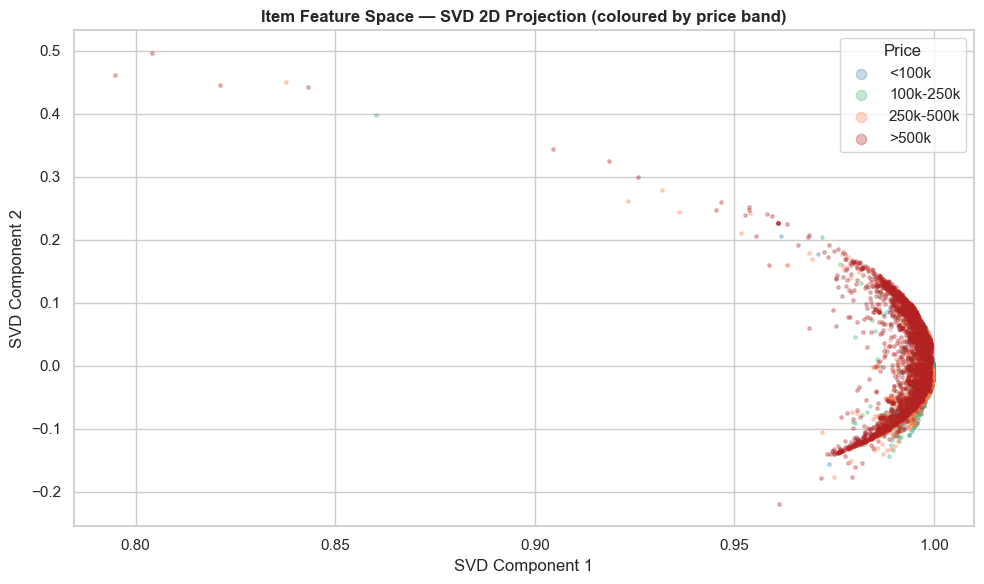

In [18]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=SEED)
coords = svd.fit_transform(item_features)
print(f'Variance explained by top 2 components: {svd.explained_variance_ratio_.sum():.2%}')

# Colour by log-price bucket for interpretability
price_labels = pd.cut(listings['price'],
                       bins=[0, 100_000, 250_000, 500_000, 5_000_000],
                       labels=['<100k', '100k-250k', '250k-500k', '>500k'])

fig, ax = plt.subplots(figsize=(10, 6))
for label, color in zip(['<100k','100k-250k','250k-500k','>500k'],
                         ['steelblue','mediumseagreen','coral','firebrick']):
    mask = price_labels == label
    ax.scatter(coords[mask, 0], coords[mask, 1], alpha=0.3, s=6, label=label, color=color)

ax.set_title('Item Feature Space — SVD 2D Projection (coloured by price band)', fontweight='bold')
ax.set_xlabel('SVD Component 1'); ax.set_ylabel('SVD Component 2')
ax.legend(title='Price', markerscale=3)
plt.tight_layout(); plt.show()

## 6. Interaction Matrix & Evaluation Framework
Build the sparse user×item matrix and define the metrics we'll track across all models.

In [19]:
def build_interaction_matrix(likes_df, user_ids, item_ids_arr):
    u2i = {int(u): i for i, u in enumerate(user_ids)}
    i2i = {int(it): i for i, it in enumerate(item_ids_arr)}
    rows = likes_df['user_id'].map(u2i)
    cols = likes_df['listing_id'].map(i2i)
    mask = rows.notna() & cols.notna()
    r = rows[mask].astype(int).to_numpy()
    c = cols[mask].astype(int).to_numpy()
    mat = sparse.coo_matrix((np.ones(len(r), dtype=np.float32), (r, c)),
                             shape=(len(user_ids), len(item_ids_arr))).tocsr()
    mat.sum_duplicates(); mat.data[:] = 1.0
    return mat, u2i, i2i

user_ids_arr = np.sort(likes['user_id'].unique())
user_items, user_to_idx, item_to_idx = build_interaction_matrix(likes, user_ids_arr, item_ids)
print(f'Interaction matrix: {user_items.shape}  nnz={user_items.nnz:,}')

Interaction matrix: (200, 26648)  nnz=26,546


In [20]:
# Hold out 20% of each user's likes as test set
rng = np.random.default_rng(SEED)

train_lil = user_items.tolil()
test_mat  = sparse.lil_matrix(user_items.shape, dtype=np.float32)

for u in range(user_items.shape[0]):
    s, e = user_items.indptr[u], user_items.indptr[u+1]
    items = user_items.indices[s:e].copy()
    if len(items) < 2:
        continue
    n_test = max(1, int(round(len(items) * 0.2)))
    n_test = min(n_test, len(items)-1)
    test_items = rng.choice(items, size=n_test, replace=False)
    for it in test_items:
        train_lil[u, int(it)] = 0.0
        test_mat[u, int(it)]  = 1.0

train_mat = train_lil.tocsr(); train_mat.eliminate_zeros()
test_mat  = test_mat.tocsr();  test_mat.eliminate_zeros()
print(f'Train interactions : {train_mat.nnz:,}')
print(f'Test  interactions : {test_mat.nnz:,}')

Train interactions : 21,229
Test  interactions : 5,317


In [21]:
def metrics_at_k(recs_by_user, test_matrix, n_items, k):
    """Compute P@K, R@K, MAP@K, NDCG@K, Coverage@K across all users."""
    prec = rec = ap = ndcg = 0.0
    rec_items = set()
    n_eval = 0
    for u in range(test_matrix.shape[0]):
        s, e = test_matrix.indptr[u], test_matrix.indptr[u+1]
        if s == e:
            continue
        n_eval += 1
        test_set = set(test_matrix.indices[s:e])
        recs = recs_by_user.get(u, [])[:k]
        rec_items.update(recs)
        hits = run_hits = dcg = user_ap = 0
        for rank, item in enumerate(recs, 1):
            if item in test_set:
                hits += 1; run_hits += 1
                dcg += 1.0 / np.log2(rank + 1)
                user_ap += run_hits / rank
        prec += hits / max(1, k)
        rec  += hits / max(1, len(test_set))
        denom = min(k, len(test_set))
        if denom:
            ap   += user_ap / denom
            idcg  = sum(1.0/np.log2(r+1) for r in range(1, denom+1))
            ndcg += dcg / idcg if idcg else 0
    if n_eval == 0:
        return dict.fromkeys(['P@K','R@K','MAP@K','NDCG@K','Cov@K'], float('nan'))
    return {
        'P@K':   prec / n_eval,
        'R@K':   rec  / n_eval,
        'MAP@K': ap   / n_eval,
        'NDCG@K':ndcg / n_eval,
        'Cov@K': len(rec_items) / max(1, n_items),
    }

K = 10
results = {}  # collect all model scores here
print(f'Evaluation at K={K} with {test_mat.shape[0]} users')

Evaluation at K=10 with 200 users


## 7. Baseline — Popularity
The simplest recommender: always suggest the most-liked listings regardless of who the user is.

In [22]:
item_popularity = np.asarray(train_mat.sum(axis=0)).ravel()
popular_order   = np.argsort(-item_popularity)

recs_popular = {}
for u in range(train_mat.shape[0]):
    s, e  = train_mat.indptr[u], train_mat.indptr[u+1]
    seen  = set(train_mat.indices[s:e])
    recs_popular[u] = [int(i) for i in popular_order if i not in seen][:K]

results['Popular'] = metrics_at_k(recs_popular, test_mat, len(item_ids), K)
print('Popular baseline:')
print({m: f"{v:.5f}" for m, v in results['Popular'].items()})

Popular baseline:
{'P@K': '0.00200', 'R@K': '0.00075', 'MAP@K': '0.00046', 'NDCG@K': '0.00178', 'Cov@K': '0.00045'}


## 8. Content-Based Model (v1) — Raw Features
Build a user profile as the **mean** of their liked listing feature vectors,
then score all unseen listings by cosine similarity.

In [23]:
def recommend_content(train_matrix, item_feat, k):
    recs = {}
    for u in range(train_matrix.shape[0]):
        s, e = train_matrix.indptr[u], train_matrix.indptr[u+1]
        liked_idx = train_matrix.indices[s:e]
        if len(liked_idx) == 0:
            recs[u] = []
            continue
        profile  = np.asarray(item_feat[liked_idx].mean(axis=0))
        profile  = normalize(profile, norm='l2')
        scores   = item_feat.dot(profile.T)
        scores   = (scores.toarray() if hasattr(scores,'toarray') else np.asarray(scores)).ravel()
        scores[liked_idx] = -np.inf
        top = np.argpartition(-scores, kth=min(k, len(scores)-1))[:k]
        recs[u] = [int(i) for i in top[np.argsort(-scores[top])]]
    return recs

# v1: item_features already uses log transforms (built earlier)
recs_content = recommend_content(train_mat, item_features, K)
results['Content-Based'] = metrics_at_k(recs_content, test_mat, len(item_ids), K)
print('Content-Based:')
print({m: f"{v:.5f}" for m, v in results['Content-Based'].items()})

Content-Based:
{'P@K': '0.00100', 'R@K': '0.00038', 'MAP@K': '0.00020', 'NDCG@K': '0.00084', 'Cov@K': '0.00450'}


## 9. Collaborative Filtering — ALS
**Alternating Least Squares (ALS)** is a matrix-factorisation algorithm designed for implicit feedback.
It decomposes the user×item interaction matrix into low-rank user and item embeddings by
alternately fixing one and solving for the other.

Internally this is equivalent to a weighted SVD on the confidence-weighted interaction matrix.
ALS is different from standard SVD in that it treats unobserved pairs as **negative evidence
with low confidence** rather than simply ignoring them.

In [24]:
als_model = implicit.als.AlternatingLeastSquares(
    factors=64, regularization=0.02, alpha=40.0, iterations=30,
    random_state=SEED,
)
als_model.fit(train_mat, show_progress=False)
print(f'ALS trained: {als_model.factors} factors  |  user factors: {als_model.user_factors.shape}  item factors: {als_model.item_factors.shape}')

ALS trained: 64 factors  |  user factors: (200, 64)  item factors: (26648, 64)


In [25]:
def recommend_als(model, train_matrix, k):
    recs = {}
    for u in range(train_matrix.shape[0]):
        ids, _ = model.recommend(u, train_matrix[u], N=k, filter_already_liked_items=True)
        recs[u] = [int(i) for i in ids]
    return recs

recs_als = recommend_als(als_model, train_mat, K)
results['ALS'] = metrics_at_k(recs_als, test_mat, len(item_ids), K)
print('ALS Collaborative Filtering:')
print({m: f"{v:.5f}" for m, v in results['ALS'].items()})

ALS Collaborative Filtering:
{'P@K': '0.00150', 'R@K': '0.00058', 'MAP@K': '0.00034', 'NDCG@K': '0.00134', 'Cov@K': '0.05483'}


### 9a. Visualising ALS Latent Space (SVD of user factors)
The 64-dimensional ALS user embeddings are projected to 2D using SVD to inspect
whether users cluster by behaviour.

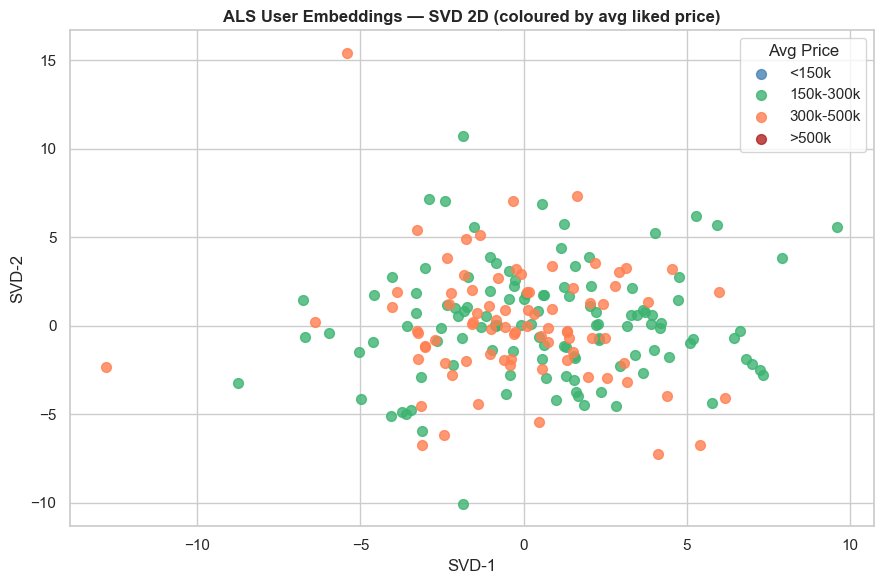

Note: no clear clusters → ALS has not learned strong collaborative patterns (expected given sparsity).


In [26]:
U = als_model.user_factors   # shape (n_users, 64)
svd2 = TruncatedSVD(n_components=2, random_state=SEED)
U2   = svd2.fit_transform(U)

# Colour by avg liked price
user_avg_price = (
    likes.merge(listings[['listing_id','price']], on='listing_id')
         .groupby('user_id')['price'].mean()
         .reindex(user_ids_arr)
)
price_band = pd.cut(user_avg_price,
                    bins=[0, 150_000, 300_000, 500_000, 5_000_000],
                    labels=['<150k','150k-300k','300k-500k','>500k'])

fig, ax = plt.subplots(figsize=(9, 6))
for band, col in zip(['<150k','150k-300k','300k-500k','>500k'],
                     ['steelblue','mediumseagreen','coral','firebrick']):
    mask = price_band.values == band
    ax.scatter(U2[mask, 0], U2[mask, 1], label=band, color=col, s=50, alpha=0.8)

ax.set_title('ALS User Embeddings — SVD 2D (coloured by avg liked price)', fontweight='bold')
ax.set_xlabel('SVD-1'); ax.set_ylabel('SVD-2')
ax.legend(title='Avg Price'); plt.tight_layout(); plt.show()
print('Note: no clear clusters → ALS has not learned strong collaborative patterns (expected given sparsity).')

## 10. Hybrid Model — Content + ALS
Blend content-based and ALS scores with a tunable weight `alpha`.
Both score vectors are min-max normalised to [0,1] before blending so neither dominates purely due to scale.

```
hybrid = alpha × content_norm + (1 - alpha) × als_norm
```

In [27]:
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return np.zeros_like(arr) if hi - lo < 1e-9 else (arr - lo) / (hi - lo)

def recommend_hybrid(train_matrix, item_feat, als_mdl, item_ids_arr, k, alpha=0.8):
    n_items = len(item_ids_arr)
    recs = {}
    for u in range(train_matrix.shape[0]):
        s, e = train_matrix.indptr[u], train_matrix.indptr[u+1]
        liked_idx = train_matrix.indices[s:e]

        # Content score
        profile  = np.asarray(item_feat[liked_idx].mean(axis=0))
        profile  = normalize(profile, norm='l2')
        c_scores = item_feat.dot(profile.T)
        c_scores = (c_scores.toarray() if hasattr(c_scores,'toarray') else np.asarray(c_scores)).ravel()

        # ALS score
        als_ids, als_raw = als_mdl.recommend(u, train_matrix[u], N=n_items,
                                              filter_already_liked_items=False)
        a_scores = np.zeros(n_items, dtype=np.float32)
        a_scores[np.asarray(als_ids, dtype=int)] = np.asarray(als_raw, dtype=np.float32)

        hybrid = alpha * minmax(c_scores) + (1 - alpha) * minmax(a_scores)
        hybrid[liked_idx] = -np.inf

        top = np.argpartition(-hybrid, kth=min(k, n_items-1))[:k]
        recs[u] = [int(i) for i in top[np.argsort(-hybrid[top])]]
    return recs

In [28]:
# Sweep alpha to find the best blend
alphas    = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ndcg_vals = []
prec_vals = []

for a in alphas:
    r = recommend_hybrid(train_mat, item_features, als_model, item_ids, K, alpha=a)
    m = metrics_at_k(r, test_mat, len(item_ids), K)
    ndcg_vals.append(m['NDCG@K'])
    prec_vals.append(m['P@K'])
    label = 'pure ALS' if a == 0 else ('pure Content' if a == 1.0 else f'alpha={a}')
    print(f'{label:<20}  NDCG@10={m["NDCG@K"]:.5f}  P@10={m["P@K"]:.5f}')

best_alpha = alphas[np.argmax(ndcg_vals)]
print(f'\nBest alpha by NDCG@10: {best_alpha}')

pure ALS              NDCG@10=0.00134  P@10=0.00150


alpha=0.2             NDCG@10=0.00127  P@10=0.00150


alpha=0.4             NDCG@10=0.00134  P@10=0.00150


alpha=0.6             NDCG@10=0.00129  P@10=0.00150


alpha=0.8             NDCG@10=0.00153  P@10=0.00100


pure Content          NDCG@10=0.00084  P@10=0.00100

Best alpha by NDCG@10: 0.8


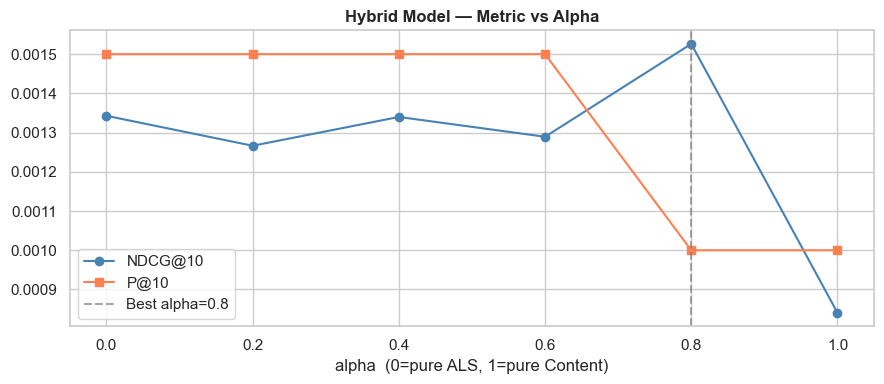

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, ndcg_vals, marker='o', color='steelblue', label='NDCG@10')
ax.plot(alphas, prec_vals, marker='s', color='coral',     label='P@10')
ax.axvline(best_alpha, linestyle='--', color='gray', alpha=0.7, label=f'Best alpha={best_alpha}')
ax.set_xlabel('alpha  (0=pure ALS, 1=pure Content)')
ax.set_title('Hybrid Model — Metric vs Alpha', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

In [30]:
recs_hybrid = recommend_hybrid(train_mat, item_features, als_model, item_ids, K, alpha=best_alpha)
results[f'Hybrid (α={best_alpha})'] = metrics_at_k(recs_hybrid, test_mat, len(item_ids), K)
print(f'Best hybrid (alpha={best_alpha}):')
print({m: f"{v:.5f}" for m, v in results[f'Hybrid (α={best_alpha})'].items()})

Best hybrid (alpha=0.8):
{'P@K': '0.00100', 'R@K': '0.00038', 'MAP@K': '0.00060', 'NDCG@K': '0.00153', 'Cov@K': '0.05186'}


## 11. Model Comparison

In [31]:
summary = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
for col in ['P@K','R@K','MAP@K','NDCG@K','Cov@K']:
    summary[col] = summary[col].astype(float).round(5)
display(summary)

,Model,P@K,R@K,MAP@K,NDCG@K,Cov@K
0,Popular,0.0020,0.00075,0.00046,0.00178,0.00045
1,Content-Based,0.0010,0.00038,0.00020,0.00084,0.00450
2,ALS,0.0015,0.00058,0.00034,0.00134,0.05483
3,Hybrid (α=0.8),0.0010,0.00038,0.00060,0.00153,0.05186


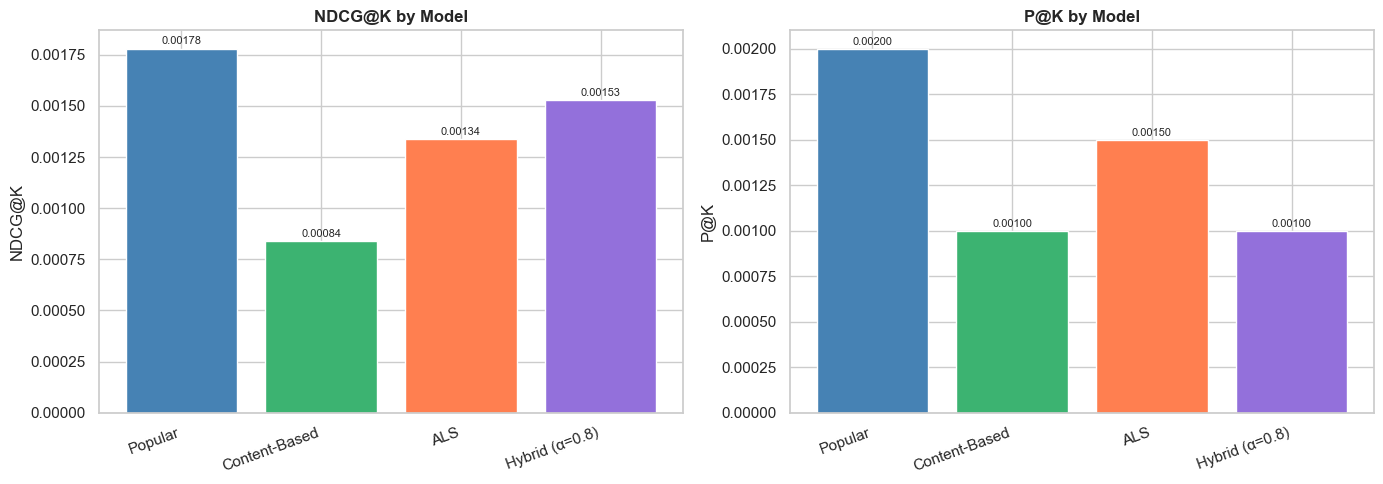

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_to_plot = ['NDCG@K', 'P@K']
models = summary['Model'].tolist()
x = np.arange(len(models))

for ax, metric in zip(axes, metrics_to_plot):
    vals = summary[metric].tolist()
    bars = ax.bar(x, vals, color=['steelblue','mediumseagreen','coral','mediumpurple'][:len(models)],
                  edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_title(f'{metric} by Model', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.00001, f'{v:.5f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

## 12. Final Recommendations for a User
Run the best model end-to-end and display the top-N listings with full details.

In [33]:
def get_recommendations(user_id, top_n=10, alpha=None):
    if alpha is None:
        alpha = best_alpha
    if user_id not in user_to_idx:
        print(f'User {user_id} not found. Valid IDs: {sorted(user_to_idx.keys())[:10]}...')
        return

    u_idx = user_to_idx[user_id]

    # User profile summary
    liked_ids  = likes[likes['user_id'] == user_id]['listing_id']
    liked_info = listings[listings['listing_id'].isin(liked_ids)]
    user_row   = users[users['user_id'] == user_id].iloc[0]
    top_cities = liked_info['city'].value_counts().head(3).index.tolist()

    print(f"User {user_id}  |  Age: {user_row['age']}  |  Gender: {user_row['gender']}  |  Education: {user_row['education']}")
    print(f"Liked {len(liked_ids)} listings  |  Avg price: ${liked_info['price'].mean():,.0f}  |  "
          f"Avg {liked_info['bed'].mean():.1f}bd / {liked_info['bath'].mean():.1f}ba  |  "
          f"Avg sqft: {liked_info['house_size'].mean():.0f}")
    print(f"Top cities in history: {', '.join(top_cities)}")

    # Scores
    s, e       = train_mat.indptr[u_idx], train_mat.indptr[u_idx+1]
    liked_idx  = train_mat.indices[s:e]
    profile    = np.asarray(item_features[liked_idx].mean(axis=0))
    profile    = normalize(profile, norm='l2')
    c_scores   = item_features.dot(profile.T)
    c_scores   = (c_scores.toarray() if hasattr(c_scores,'toarray') else np.asarray(c_scores)).ravel()

    als_ids, als_raw = als_model.recommend(u_idx, train_mat[u_idx], N=len(item_ids),
                                            filter_already_liked_items=False)
    a_scores = np.zeros(len(item_ids), dtype=np.float32)
    a_scores[np.asarray(als_ids, dtype=int)] = np.asarray(als_raw, dtype=np.float32)

    hybrid = alpha * minmax(c_scores) + (1-alpha) * minmax(a_scores)
    hybrid[liked_idx] = -np.inf

    top_idx  = np.argsort(-hybrid)[:top_n]
    top_lids = item_ids[top_idx]
    top_scrs = hybrid[top_idx]

    recs = listings[listings['listing_id'].isin(top_lids)].copy()
    recs['score'] = recs['listing_id'].map(dict(zip(top_lids, top_scrs)))
    recs = recs.sort_values('score', ascending=False).reset_index(drop=True)
    recs.index += 1

    show_cols = [c for c in ['listing_id','price','bed','bath','house_size','acre_lot','city','status','score'] if c in recs.columns]
    return recs[show_cols]

# --- Run for a sample user ---
display(get_recommendations(user_id=1, top_n=10))

User 1  |  Age: 69  |  Gender: Other  |  Education: Post Graduation
Liked 131 listings  |  Avg price: $337,206  |  Avg 3.3bd / 2.3ba  |  Avg sqft: 2108
Top cities in history: Birmingham, Gulf Shores, Tuscaloosa


,listing_id,price,bed,bath,house_size,acre_lot,city,status,score
1,17169,319000,4,4,2200,0.85,Troy,for_sale,0.946674
2,19095,141000,3,2,1980,0.42,Auburn,for_sale,0.929998
3,25522,199900,3,2,1980,2.03,Theodore,for_sale,0.926005
4,13561,90000,3,2,1500,0.45,Florence,for_sale,0.925522
5,7212,202080,3,2,1202,0.18,Mount Olive,for_sale,0.925384
6,26985,420699,4,2,2789,0.70,Opelika,ready_to_build,0.921812
7,9687,98500,3,2,1980,0.70,Arley,for_sale,0.921396
8,10547,69900,3,2,1980,1.00,Glencoe,for_sale,0.920453
9,18803,325000,3,2,1980,1.00,Ozark,for_sale,0.920130
10,27049,315099,3,3,2156,0.21,Opelika,for_sale,0.919831


In [34]:
# Compare recommendations for three different users side by side
for uid in [1, 50, 150]:
    print(f'\n{"="*70}')
    display(get_recommendations(user_id=uid, top_n=5))


User 1  |  Age: 69  |  Gender: Other  |  Education: Post Graduation
Liked 131 listings  |  Avg price: $337,206  |  Avg 3.3bd / 2.3ba  |  Avg sqft: 2108
Top cities in history: Birmingham, Gulf Shores, Tuscaloosa


,listing_id,price,bed,bath,house_size,acre_lot,city,status,score
1,17169,319000,4,4,2200,0.85,Troy,for_sale,0.946674
2,19095,141000,3,2,1980,0.42,Auburn,for_sale,0.929998
3,25522,199900,3,2,1980,2.03,Theodore,for_sale,0.926005
4,13561,90000,3,2,1500,0.45,Florence,for_sale,0.925522
5,7212,202080,3,2,1202,0.18,Mount Olive,for_sale,0.925384



User 50  |  Age: 36  |  Gender: Female  |  Education: High School
Liked 132 listings  |  Avg price: $292,785  |  Avg 3.2bd / 2.3ba  |  Avg sqft: 2093
Top cities in history: Fairhope, Birmingham, Gulf Shores


,listing_id,price,bed,bath,house_size,acre_lot,city,status,score
1,22027,49000,3,2,1980,0.70,Bay Minette,for_sale,0.938474
2,5996,40000,3,2,1980,3.02,Odenville,for_sale,0.927267
3,6062,417900,4,3,2219,0.70,Leeds,for_sale,0.919150
4,4529,144900,3,2,1800,2.04,Vandiver,for_sale,0.918949
5,21444,18000,3,2,1980,0.75,Brewton,for_sale,0.917730



User 150  |  Age: 45  |  Gender: Male  |  Education: No Education
Liked 130 listings  |  Avg price: $345,321  |  Avg 3.3bd / 2.4ba  |  Avg sqft: 2164
Top cities in history: Mobile, Birmingham, Tuscaloosa


,listing_id,price,bed,bath,house_size,acre_lot,city,status,score
1,8385,491700,3,2,2324,0.70,Hoover,for_sale,0.938381
2,25674,80000,3,2,1980,3.00,Robertsdale,for_sale,0.928449
3,12459,149000,3,2,1980,0.70,Arley,for_sale,0.927688
4,20481,19900,3,2,1980,0.70,Weaver,for_sale,0.920769
5,20349,249900,3,2,1622,4.45,Five Points,for_sale,0.920399
